# 05 - Optimizacion de tasas por sub_grade (Fase 8)

A partir de aquí, `i` indexa los 35 sub_grades (A1...G5) -- ver `04_aggregation_subgrade.ipynb` para cómo se agregaron `p_{i,k}`, `PD_i`, `LGD_i`, `P_i` (monto medio) y `n_i` (plazo medio) desde los modelos individuales hasta este nivel.

Se construyen y comparan dos versiones de función objetivo, resueltas con PuLP:

- **REVENUE** (ingenua): `max Σ r_k·n_i·P_i·p_{i,k}·x[i,k]` -- ingreso bruto esperado, ignora costo de fondeo y pérdida esperada.
- **PROFITABILITY** (Phillips, Ecuación 4-5): `max Σ P_i·p_{i,k}·(n_i·(r_k-c) - PD_i·LGD_i)·x[i,k]` -- resta la pérdida esperada directamente del margen bruto.

Restricciones: una tasa por sub_grade, `c ≤ r ≤ r_max` (implícito en `RATE_GRID`), y monotonicidad de riesgo (sub_grades más riesgosos reciben tasa ≥ que sub_grades menos riesgosos).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.optimization import add_objective_terms, build_optimization_table, solve_pricing  # noqa: E402
from src.risk_model import FUNDING_COST_BASE  # noqa: E402

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (10, 5)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

subgrade_params = pd.read_csv(PROCESSED_DIR / "subgrade_params.csv")
elasticity = pd.read_csv(PROCESSED_DIR / "subgrade_elasticity.csv")

table = build_optimization_table(subgrade_params, elasticity)
table = add_objective_terms(table, funding_cost=FUNDING_COST_BASE)

print(f"table: {table.shape} (35 sub_grades x 15 tasas = 525 combinaciones -> 525 variables binarias)")
table.head()

table: (525, 15) (35 sub_grades x 15 tasas = 525 combinaciones -> 525 variables binarias)


,sub_grade,tasa,p_aceptacion,PD,LGD,n_chargeoff,n_clients,LGD_source,P_i,n_i,D_i,n_years,revenue_term,profit_term,volume_term
0,A1,5.00,0.807942,0.0787,0.903536,101,5755,modelado,15169.782798,36.629713,5755,3.052476,1870.602796,-310.343332,12256.297707
1,A1,6.79,0.793285,0.0787,0.903536,101,5755,modelado,15169.782798,36.629713,5755,3.052476,2494.197816,352.814160,12033.967852
2,A1,8.57,0.778294,0.0787,0.903536,101,5755,modelado,15169.782798,36.629713,5755,3.052476,3088.559435,987.644326,11806.546118
3,A1,10.36,0.762851,0.0787,0.903536,101,5755,modelado,15169.782798,36.629713,5755,3.052476,3659.577807,1600.349057,11572.280621
4,A1,12.14,0.747182,0.0787,0.903536,101,5755,modelado,15169.782798,36.629713,5755,3.052476,4200.262791,2183.331334,11334.581850


In [2]:
result_revenue = solve_pricing(table, objective="revenue")
result_profit = solve_pricing(table, objective="profitability")

print(f"REVENUE       -- status: {result_revenue['status']}")
print(f"PROFITABILITY -- status: {result_profit['status']}")

REVENUE       -- status: Optimal
PROFITABILITY -- status: Optimal


In [3]:
comparison = result_revenue["assignment"][["sub_grade", "tasa_asignada", "PD", "LGD"]].rename(
    columns={"tasa_asignada": "tasa_revenue"}
)
comparison = comparison.merge(
    result_profit["assignment"][["sub_grade", "tasa_asignada"]].rename(
        columns={"tasa_asignada": "tasa_profitability"}
    ),
    on="sub_grade",
)
comparison["diferencia"] = comparison["tasa_profitability"] - comparison["tasa_revenue"]
comparison

,sub_grade,tasa_revenue,PD,LGD,tasa_profitability,diferencia
0,A1,30.0,0.078700,0.903536,30.0,0.0
1,A2,30.0,0.088061,0.906946,30.0,0.0
2,A3,30.0,0.099767,0.907448,30.0,0.0
3,A4,30.0,0.115982,0.908278,30.0,0.0
4,A5,30.0,0.126042,0.907533,30.0,0.0
5,B1,30.0,0.145947,0.908632,30.0,0.0
6,B2,30.0,0.159011,0.908358,30.0,0.0
7,B3,30.0,0.169307,0.907313,30.0,0.0
8,B4,30.0,0.182454,0.908307,30.0,0.0
9,B5,30.0,0.190975,0.908191,30.0,0.0


## Hallazgo honesto: REVENUE y PROFITABILITY convergen en la tasa techo (30%) para todos los sub_grades

Este resultado no es un error del optimizador -- es una consecuencia directa y correcta de dos hechos ya establecidos en fases anteriores:

1. **La elasticidad de demanda medida (Fase 6) es inelástica en todo el rango 5%-30%**: `p_{i,k}` cae de forma suave pero moderada (ej. de ~0.81 a ~0.58 para A1), nunca lo bastante rápido como para que `r × p(r)` (el ingreso) empiece a decrecer dentro del rango candidato. Sin un punto donde subir la tasa deje de compensar la pérdida de clientes, **REVENUE** siempre elige el techo -- eso es exactamente lo que se espera de una función objetivo que no penaliza el riesgo.

2. **`PD_i` y `LGD_i` son fijos por sub_grade, no dependen de la tasa candidata** (es la simplificación explícita de la versión base de este proyecto -- Concepto clave 5 del README, Phillips mismo lo trata como problema abierto). Como consecuencia, la penalización de pérdida esperada (`PD_i·LGD_i`) entra en la fórmula de **PROFITABILITY** como una constante que se resta del margen, **no como algo que crece con la tasa**. Estructuralmente, eso significa que si el margen bruto (`n_i·(r-c)`) es creciente en `r` en todo el rango, la utilidad también lo es -- no hay mecanismo, en la versión base, para que la utilidad tenga un máximo interior antes del techo.

**Esto es precisamente la limitación que Phillips (2013) señala como "problema abierto"** (selección adversa por precio, riesgo dependiente de la tasa): si `PD` dependiera de `r` (los clientes que aceptan tasas altas siendo malos pagadores, empeorando el mix conforme sube la tasa), la utilidad sí podría tener un máximo interior más bajo que el de revenue. La versión base de este proyecto no lo modela (ver limitación documentada en el README) -- es una extensión reconocida, no un defecto de esta implementación.

### La "trampa de revenue" sigue siendo real -- se manifiesta como brecha de valoración, no de tasa

Aunque ambas versiones recomiendan la misma tasa, **REVENUE sobreestima sistemáticamente cuánto vale realmente cada préstamo**, porque nunca resta la pérdida esperada. Esa brecha es mayor en los sub_grades más riesgosos -- es la forma concreta en que se materializa el riesgo de "maximizar solo ingreso": un analista que mire solo `revenue_term` creería que los sub_grades G son casi tan rentables como los A, cuando en realidad una fracción grande de ese ingreso está destinada a cubrir pérdidas esperadas.

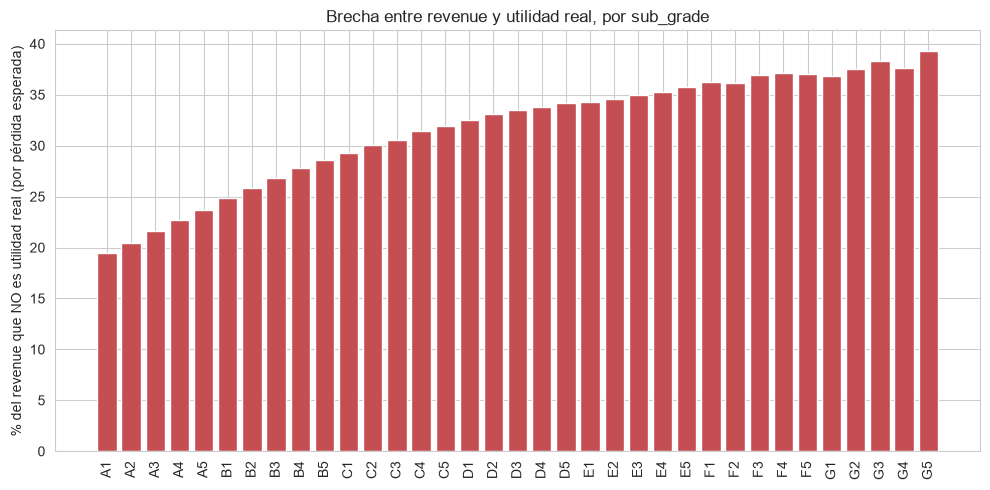

sub_grade  tasa_asignada  revenue_term  profit_term       PD  brecha_pct
       G5           30.0  14209.148877  8619.754401 0.412030    0.393366
       G3           30.0  16913.345771 10435.699135 0.403692    0.382990
       G4           30.0  19226.170408 11996.919084 0.403206    0.376011
       G2           30.0  17461.530565 10904.073092 0.392829    0.375537
       F4           30.0  16154.013865 10157.501772 0.390510    0.371209


In [4]:
value_gap = result_profit["assignment"][
    ["sub_grade", "tasa_asignada", "revenue_term", "profit_term", "PD"]
].copy()
value_gap["brecha_pct"] = 1 - value_gap["profit_term"] / value_gap["revenue_term"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(value_gap["sub_grade"], value_gap["brecha_pct"] * 100, color="#C44E52")
ax.set_ylabel("% del revenue que NO es utilidad real (por pérdida esperada)")
ax.set_title("Brecha entre revenue y utilidad real, por sub_grade")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

print(value_gap.sort_values("brecha_pct", ascending=False).head(5).to_string(index=False))

## Análisis de sensibilidad: costo de fondeo (`r_c`)

Como se documentó en la Fase 7, el costo de fondeo es un supuesto (LendingClub no lo reporta). Se corre PROFITABILITY con los 3 escenarios de `FUNDING_COST_SENSITIVITY` para ver cuánto cambia la utilidad total del portafolio -- dado que `PD_i·LGD_i` es constante en `r`, el cambio en `c` no altera qué tasa es óptima (sigue siendo el techo para todos), pero sí cambia el nivel de utilidad estimada.

In [5]:
from src.risk_model import FUNDING_COST_SENSITIVITY

sensitivity_rows = []
for c in FUNDING_COST_SENSITIVITY:
    table_c = add_objective_terms(build_optimization_table(subgrade_params, elasticity), funding_cost=c)
    res_c = solve_pricing(table_c, objective="profitability")
    sensitivity_rows.append(
        {"funding_cost": c, "total_profit": res_c["total_profit"], "total_volume": res_c["total_volume"]}
    )

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df

,funding_cost,total_profit,total_volume
0,0.02,293627.185530,339055.017602
1,0.04,266402.668556,339055.017602
2,0.06,239178.151583,339055.017602


In [6]:
table.to_csv(PROCESSED_DIR / "optimization_table.csv", index=False)
print("Guardado:", PROCESSED_DIR / "optimization_table.csv")

print()
print("Resumen Fase 8:")
print(f"  Total volumen (PROFITABILITY): ${result_profit['total_volume']:,.0f}")
print(f"  Total utilidad (PROFITABILITY): ${result_profit['total_profit']:,.0f}")
print(f"  Total revenue (REVENUE):        ${result_revenue['total_revenue']:,.0f}")

Guardado: C:\Users\josue\credit-pricing-optimizer\data\processed\optimization_table.csv

Resumen Fase 8:
  Total volumen (PROFITABILITY): $339,055
  Total utilidad (PROFITABILITY): $273,209
  Total revenue (REVENUE):        $408,368


## Resumen y próximos pasos

- `src/optimization.py` implementa REVENUE y PROFITABILITY (Ecuaciones 4-5 de Phillips) con PuLP, con restricciones de una tasa por segmento y monotonicidad de riesgo.
- Hallazgo honesto: con `PD`/`LGD` fijos (no dependientes de la tasa, limitación reconocida de la versión base) y la elasticidad medida en la Fase 6, ambas versiones convergen en la tasa techo para todos los sub_grades -- consecuencia matemática correcta, no un error, y consistente con lo que Phillips (2013) señala como problema abierto.
- La "trampa de revenue" se manifiesta como una brecha de valoración (revenue sobreestima la rentabilidad real, más en segmentos riesgosos), no como una divergencia de tasa recomendada.
- Próximo notebook: `06_efficient_frontier.ipynb` -- variando la restricción de volumen mínimo `B`, se construyen 5 escenarios que sí generan variación real en las tasas recomendadas (la restricción de volumen obliga a bajar la tasa en los sub_grades más elásticos para alcanzar el volumen objetivo).